# EXPRES Tutorial

This notebook shows how to translate native EXPRES products into the EPRV data standard at Levels 2, 3 and 4.

EXPRES produces two files per exposure with the same basename:

* `fitspec/<name>.fits`: the optimally extracted spectrum (input for L2 and L3)
* `ccf/<name>.fits`: the cross-correlation function and RVs (input for L4, together with the fitspec file)

The example exposure is a solar observation from 2024-01-26. Set `EXPRES_FIXTURE_DIR` to a directory holding `fitspec/` and `ccf/` subdirectories, or let the helper download it.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from rvdata.core.models.level2 import RV2
from rvdata.core.models.level3 import RV3
from rvdata.core.models.level4 import RV4
from rvdata.tests.regression.test_expres import expres_fixture_files

fitspec_file, ccf_file = expres_fixture_files()
fitspec_file, ccf_file

('/private/tmp/claude-501/-opt-web-sites-agents-vera/3f877c57-237c-4cab-8178-75987107bc81/scratchpad/expres_fixtures/fitspec/Sun_20240126.5073.fits',
 '/private/tmp/claude-501/-opt-web-sites-agents-vera/3f877c57-237c-4cab-8178-75987107bc81/scratchpad/expres_fixtures/ccf/Sun_20240126.5073.fits')

## Level 2: extracted spectrum

`RV2.from_fits` reads the fitspec file. Flux is the native `spectrum` multiplied back by the blaze, variance is scaled the same way, and wavelengths are in vacuum Angstrom.

In [2]:
l2 = RV2.from_fits(fitspec_file, instrument="EXPRES")
h = l2.headers["PRIMARY"]
{k: h[k] for k in ("INSTRUME", "OBJECT", "ISSOLAR", "DATE-OBS", "EXPTIME", "INSTERA", "DRPTAG")}

{'INSTRUME': 'EXPRES',
 'OBJECT': 'Sun',
 'ISSOLAR': True,
 'DATE-OBS': '2024-01-26T16:52:41.874',
 'EXPTIME': 600.0029999999967,
 'INSTERA': '5.10.0',
 'DRPTAG': '0.4.1'}

In [3]:
l2.data["EXT_DESCRIPT"]

Name,Description
str17,str100
PRIMARY,EPRV Standard FITS HEADER (no data)
INSTRUMENT_HEADER,Inherited EXPRES fitspec primary header (no data)
RECEIPT,Table of operations that have been performed on this file
DRP_CONFIG,Pipeline details (settings etc) to go from native data to L2
EXT_DESCRIPT,Table describing contents of each extension
ORDER_TABLE,Table capturing the wavelength extent of each order in Trace 1
TRACE1_FLUX,Extracted flux in trace 1 (native spectrum x blaze)
TRACE1_WAVE,Vacuum wavelength solution for trace 1 (Angstrom)
TRACE1_VAR,Variance of TRACE1_FLUX


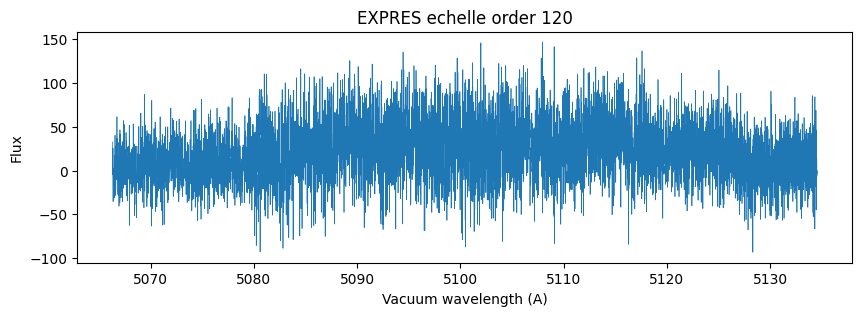

In [4]:
order = 40  # ORDER_INDEX; echelle order 160 - 40 = 120
wave = l2.data["TRACE1_WAVE"][order]
flux = l2.data["TRACE1_FLUX"][order]
plt.figure(figsize=(10, 3))
plt.plot(wave, flux, lw=0.5)
plt.xlabel("Vacuum wavelength (A)"); plt.ylabel("Flux")
plt.title(f"EXPRES echelle order {l2.data['ORDER_TABLE']['ECHELLE_ORDER'][order]}")
plt.show()

In [5]:
l2_file = l2.to_fits()
l2_file

'/private/tmp/claude-501/-opt-web-sites-agents-vera/3f877c57-237c-4cab-8178-75987107bc81/scratchpad/RVData/docs/source/tutorials/expres_SL2_20240126T165241.fits'

## Level 3: stitched spectrum

The L3 translator reads the same fitspec file, deblazes the science trace and stitches orders 160 to 76 onto a common grid from 3800 to 8100 A.

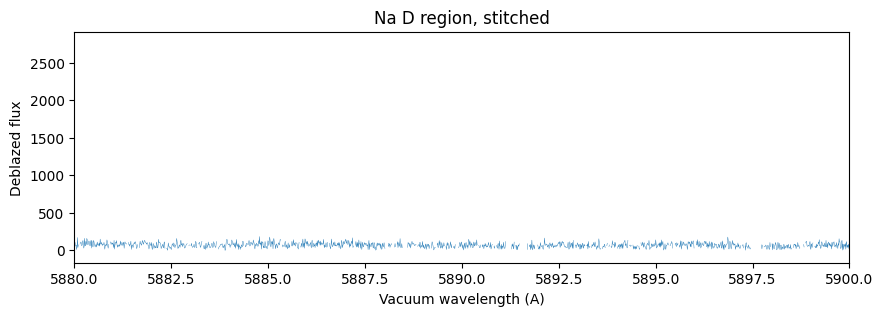

'/private/tmp/claude-501/-opt-web-sites-agents-vera/3f877c57-237c-4cab-8178-75987107bc81/scratchpad/RVData/docs/source/tutorials/expres_SL3_20240126T165241.fits'

In [6]:
l3 = RV3.from_fits(fitspec_file, instrument="EXPRES")
wave3 = l3.data["STITCHED_CORR_SCI_WAVE"]
flux3 = l3.data["STITCHED_CORR_SCI_FLUX"]
plt.figure(figsize=(10, 3))
plt.plot(wave3, flux3, lw=0.3)
plt.xlim(5880, 5900); plt.xlabel("Vacuum wavelength (A)"); plt.ylabel("Deblazed flux")
plt.title("Na D region, stitched"); plt.show()
l3.to_fits()

## Level 4: radial velocities

The L4 translator takes the ccf file and finds the fitspec file in the sibling `fitspec/` directory (or pass `l1_file=`). Velocities are converted from the native cm/s to km/s.

In [7]:
l4 = RV4.from_fits(ccf_file, instrument="EXPRES")
h4 = l4.headers["PRIMARY"]
{k: h4[k] for k in ("BJDTDB", "RV", "RVERR", "BERV", "RVMETHOD", "SYSVEL")}

{'BJDTDB': 2460336.2018426233,
 'RV': -0.59761279,
 'RVERR': 0.07167932,
 'BERV': -0.5935112263905817,
 'RVMETHOD': 'CCF',
 'SYSVEL': 0.0}

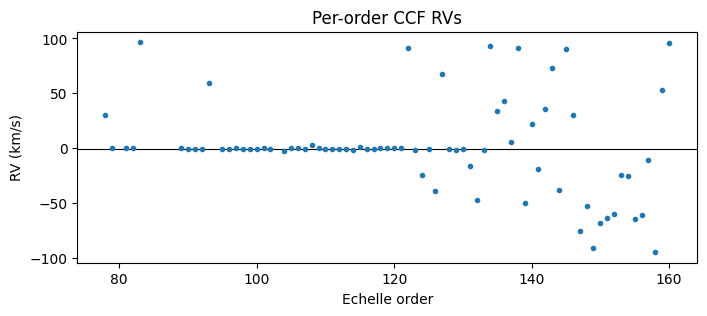

metric_name,value,uncertainty
str8,float64,float64
S-VALUE,--,--
HALPHA,-0.3561308233809938,--
HWIDTH,1.86439617787058,--
CCFFWHM,7394.068259067368,124.0304824749664
BIS,-51.39066670897762,--
CCFVSPAN,127.3697773559743,--
BIGAUSS,6.901229317227035,--
SKEWNORM,0.01416044379571991,--
QUALITY,0.9297927382097597,--


In [8]:
rv1 = l4.data["RV1"]
plt.figure(figsize=(8, 3))
plt.errorbar(rv1["ECHELLE_ORDER"], rv1["RV"], rv1["RV_ERR"], fmt=".")
plt.axhline(h4["RV"], color="k", lw=0.8)
plt.xlabel("Echelle order"); plt.ylabel("RV (km/s)"); plt.title("Per-order CCF RVs")
plt.show()
l4.data["DIAGNOSTICS1"]

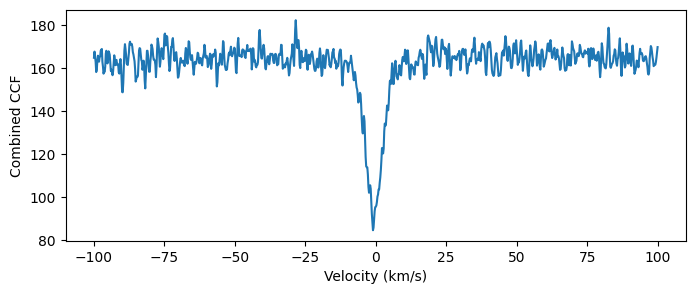

'/private/tmp/claude-501/-opt-web-sites-agents-vera/3f877c57-237c-4cab-8178-75987107bc81/scratchpad/RVData/docs/source/tutorials/expres_SL4_20240126T165241.fits'

In [9]:
vel = l4.headers["CCF1"]["CCFSTART"] + l4.headers["CCF1"]["CCFSTEP"] * np.arange(l4.headers["CCF1"]["VELNSTEP"])
plt.figure(figsize=(8, 3))
plt.plot(vel, l4.data["CUSTOM_CCF1"][0])
plt.xlabel("Velocity (km/s)"); plt.ylabel("Combined CCF"); plt.show()
l4.to_fits()